<h1>Monstro da Semana 1: Kobold</h1>

<h4><i>Bruno Bini Camargo</i></h4>

<h2>Introdução</h2> 

A estatística descritiva é uma área da estatística responsável por descrever e resumir um conjunto de dados. Nessa área de estudo, existem 4 tipos de dados: quantitativo contínuo, quantitativo discreto, qualitativo ordinal e qualitativo nominal. 
Os dados quantitativos expressam quantidades numéricas que podem ser usadas para efetuar operações. Dentre esses, há os contínuos, que podem assumir qualquer valor dentro de um intervalo; e os discretos, que, ao contrário dos contínuos, podem assumir apenas valores inteiros de contagens. 
Já os dados qualitativos categorizam as observações em grupos com base em suas características. Dentre eles, encontram-se os ordinais, que estão presentes em agrupamentos que permitem ordenação; e os nominais, que não podem ser ordenados. 

Dados como esses podem ser encontrados em censos, ou seja, levantamentos estatísticos capazes de trazerem informações descritivas sobre uma população. Nesse notebook, a partir do conjunto de dados coletados em um censo realizado com os alunos da Ilum Escola de Ciência, serão analisados dados pertencentes a essas 4 categorias. O objetivo deste trabalho é analisar de forma exploratória os dados, calculando estatísticas descritivas, construindo gráficos para visualizar padrões dos estudantes, discutindo os resultados observados e testando hipóteses baseadas na comparação das variáveis aleatórias. 

<h2>Desenvolvimento</h2>

Inicialmente, vamos transformar os dados do censo, que estão em uma planilha Excel, para o formato de Data Frame do Python, por meio do módulo pandas.

In [1]:
import pandas as pd
import statistics as st

df = pd.read_excel("Censo Ilum.xlsx")

<h3>Hábitos dos alunos</h3>

Visando entender a rotina dos alunos, vamos analisar as horas de sono, em média, por noite e a quantidade de livros lidos no ano anterior à pesquisa.

A variável aleatória "Quantas horas (em média) você dorme por noite?" é um dado quantitativo contínuo. Durante a análise dos dados coletados, notou-se erros de digitação, uma vez que uma noite dura cerca de 12 horas e alguns dados informavam tempos muito acima desse limite, como 55h e 75h. 
Para resolver esse problema, visto que o erro aparenta ser a ausência de uma vírgula separando os algarismos, dividiu-se os valores acima de 12h por 10, de forma a integrá-los à pesquisa. 

In [2]:
horas_sono = df["Quantas horas (em média) você dorme por noite?"].dropna()

lista_horas = []
for valor in horas_sono:
    if valor > 12:
        lista_horas.append(valor / 10)
    else:
        lista_horas.append(valor)

df['Horas de sono (limpas)'] = pd.Series(lista_horas, index=horas_sono.index)

média_sono = st.mean(lista_horas)
desv_pad = st.pstdev(lista_horas)
mediana_sono = st.median(lista_horas)
moda_sono = st.mode(lista_horas)

print(f"A média de horas de sono é{média_sono: .1f} h, com desvio padrão de{desv_pad: .2f} h.")
print(f"A mediana de horas de sono é {mediana_sono} h.")
print(f"A moda de horas de sono é {moda_sono} h.")

A média de horas de sono é 6.9 h, com desvio padrão de 0.98 h.
A mediana de horas de sono é 7.0 h.
A moda de horas de sono é 7.0 h.


Analisando-se essas medidas, percebe-se que a média, a mediana e a moda apresentam valores praticamente idênticos (em torno de 7h), o que indica uma distribuição bastante simétrica dos dados. Além disso, o baixo desvio padrão (0.98 h) confirma que o tempo de sono dos alunos da Ilum é pouco disperso e concentrado em torno de 7h por noite.

Agora, vamos tomar como base outro hábito dos alunos: a leitura. Vejamos a quantidade de livros lidos no ano anterior à pesquisa, um dado quantitativo discreto: 

In [3]:
livros_lidos = df["Quantos livros você leu no ano passado?"].dropna()

média_livros = st.mean(livros_lidos)
desv_pad_livros = st.pstdev(livros_lidos)
mediana_livros = st.median(livros_lidos)
moda_livros = st.mode(livros_lidos)

quartis = st.quantiles(livros_lidos, n=4, method="inclusive")

primeiro_quartil = quartis[0]
terceiro_quartil = quartis[2]

iqr = terceiro_quartil - primeiro_quartil

print(f"A média de livros lidos é{média_livros: .1f} livros, com desvio padrão de{desv_pad_livros: .1f} livros.")
print(f"A mediana de livros lidos é {mediana_livros} livros.")
print(f"A moda de livros lidos é {moda_livros} livros.")
print(f"O valor do IQR é {iqr:.1f} livros.")

A média de livros lidos é 10.5 livros, com desvio padrão de 12.9 livros.
A mediana de livros lidos é 7.0 livros.
A moda de livros lidos é 5.0 livros.
O valor do IQR é 8.0 livros.


Apesar da média de 10.5 livros, é perceptível através da mediana que 50% das pessoas leram até 7 livros e que o número mais frequente foi 5 livros. O intervalo interquartil (IQR = 8.00) melhora essa análise ao isolar a metade central da turma. Esse valor de 8 livros mostra que, mesmo dentro desse núcleo de estudantes, existe uma variação significativa de comportamento, com uma diferença de 8 livros entre a parte inferior e superior desse grupo.
O desvio padrão de 12.9 livros corrobora em demonstrar a heterogeneidade da quantidade de livros lidos por este grupo de alunos.

O gráfico abaixo mostra a distribuição da quantidade de livros lidos entre os alunos da Ilum e mostra visualmente o que foi indicado pelas estatísticas descritivas acima:

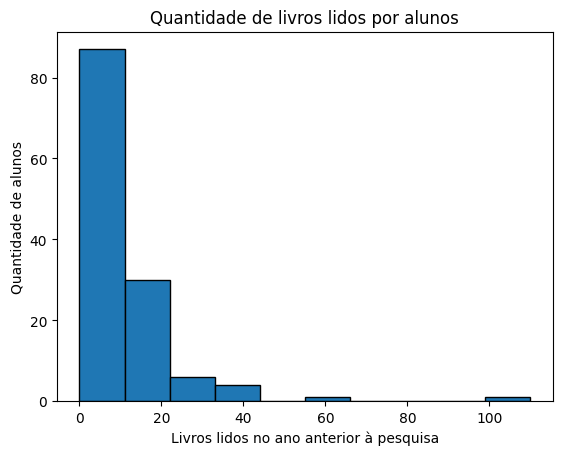

In [4]:
import matplotlib.pyplot as plt

plt.hist(livros_lidos, edgecolor="black")

plt.xlabel("Livros lidos no ano anterior à pesquisa")
plt.ylabel("Quantidade de alunos")
plt.title("Quantidade de livros lidos por alunos")

plt.show()

Agora apresento uma hipótese que relaciona esses dois hábitos dos alunos: pessoas que dormem mais leem mais livros, já que usam o livro como forma de relaxamento para uma melhor noite de sono. Vamos comparar graficamente as medidas das observações das duas variáveis aleatórias já estudadas (horas de sono e livros lidos) para ver se minha hipótese se confirma.

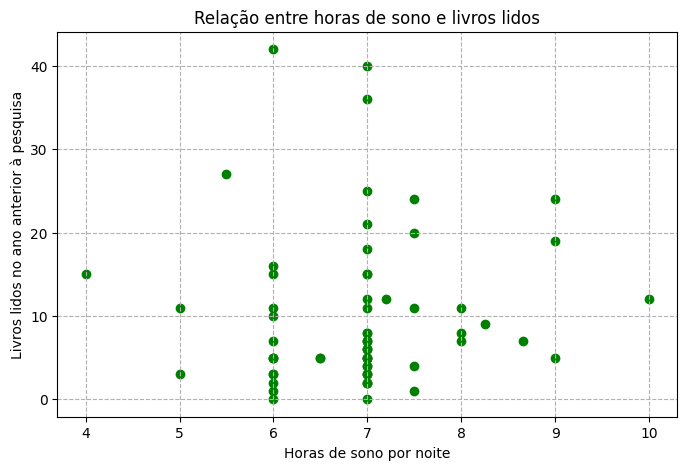

In [5]:
df_comp = df[['Horas de sono (limpas)', 'Quantos livros você leu no ano passado?']].dropna()

horas_comp = df_comp['Horas de sono (limpas)'].tolist()
livros_comp = df_comp['Quantos livros você leu no ano passado?'].tolist()

plt.figure(figsize=(8, 5))
plt.scatter(horas_comp, livros_comp, color='green')

plt.title("Relação entre horas de sono e livros lidos")
plt.xlabel("Horas de sono por noite")
plt.ylabel("Livros lidos no ano anterior à pesquisa")
plt.grid(True, linestyle='--')

plt.show()

Analisando o gráfico comparativo, percebemos que minha hipótese de livros lidos e horas de sono serem grandezas diretamente proporcionais está equivocada. Entretanto, desse gráfico ainda podemos retirar uma informação valiosa: a maior variabilidade na quantidade de livros lidos se concentra justamente nos alunos que dormem 7h em média por noite, que são a maioria, como indicado pela mediana, moda e média dos dados de horas de sono.

<h3>Mês de nascimento e lateralidade: há alguma relação entre eles?</h3>

Agora vamos nos atentar ao mês de nascimento, um dado qualitativo ordinal. 

In [6]:
mapa_meses = {
    1: 'janeiro', 2: 'fevereiro', 3: 'março', 4: 'abril',
    5: 'maio', 6: 'junho', 7: 'julho', 8: 'agosto',
    9: 'setembro', 10: 'outubro', 11: 'novembro', 12: 'dezembro'
}

meses = df["Qual o mês do seu aniversário?"].dropna().astype(int)

moda_num = st.mode(meses)

moda_nome = mapa_meses[moda_num]

print(f"A moda dos meses de nascimento é {moda_nome}.")

A moda dos meses de nascimento é maio.


Esse dado nos mostra que a maior parte dos alunos da Ilum nasceu em maio.

Tomando agora a lateralidade como base, um dado qualitativo nominal:

In [7]:
lateralidade = df["Qual das opções abaixo melhor te representa?"].dropna()

freq_absoluta = lateralidade.value_counts()
freq_relativa = (lateralidade.value_counts(normalize=True) * 100).round(2)

tabela = pd.DataFrame({
    'Lateralidade': freq_relativa.index,
    'Quantidade de alunos': freq_absoluta.values,
    'Porcentagem (%)': freq_relativa.values
})

print(tabela.to_string(index=False))

  Lateralidade  Quantidade de alunos  Porcentagem (%)
    Sou destro                    65            92.86
   Sou canhoto                     4             5.71
Sou ambidestro                     1             1.43


Percebemos que a esmagadora maioria dos alunos da Ilum é destra, seguida por uma minoria de canhotos e uma parcela ínfima de ambidestros, o que reflete a tendência da dominância da mão direita.

Vamos agora verificar a grande questão dessa seção de análise: há alguma relação entre a mão dominante de uma pessoa e seu mês de nascimento?

Segundo o estudo "A large-scale population study of early life factors influencing lefthandedness" [1], publicado na Nature, com base em dados do UK Biobank, há uma leve correlação entre a estação do ano em que a pessoa nasceu e a probabilidade de ser canhoto, relacionada a fatores gestacionais e à exposição solar. O estudo britânico aponta maior proporção de canhotos em nascimentos ocorridos no verão.

A partir disso, vamos conferir se essa lógica se aplica ao nosso censo, por meio de um gráfico de dispersão:

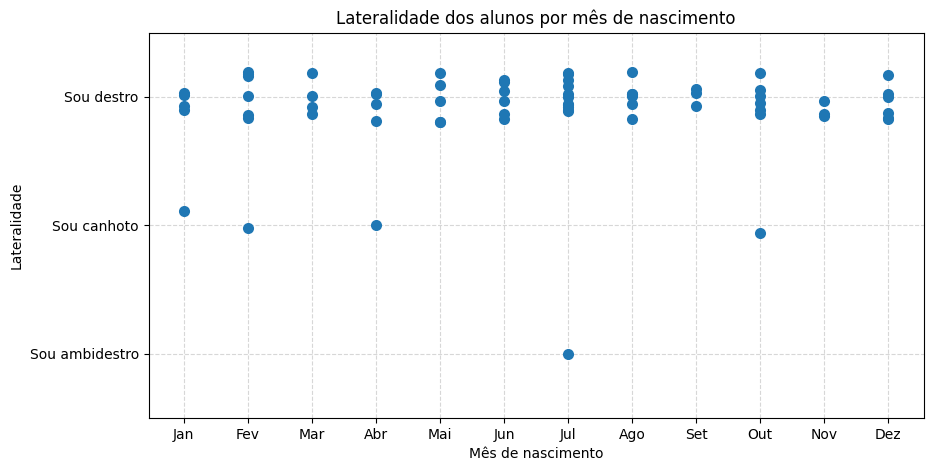

In [8]:
import seaborn as sns

meses_siglas = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

plt.figure(figsize=(10, 5))

sns.stripplot(
    data=df, 
    x='Qual o mês do seu aniversário?', 
    y='Qual das opções abaixo melhor te representa?',
    size=8,
    jitter=0.2
)

plt.xticks(ticks=range(1, 13), labels=meses_siglas)

plt.title("Lateralidade dos alunos por mês de nascimento")
plt.xlabel("Mês de nascimento")
plt.ylabel("Lateralidade")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

É possível observar que os alunos destros estão distribuídos de forma contínua ao longo de todos os meses, enquanto os 4 alunos canhotos nasceram nos meses de janeiro, fevereiro, abril e outubro, e o único aluno ambidestro nasceu em julho.

Ao comparar os dados do censo com a pesquisa científica, observamos que a ideia de que a época do ano influencia a mão dominante não se confirmou no gráfico. Isso acontece principalmente porque o número de alunos analisados é muito pequeno, enquanto o estudo da Nature utilizou informações de centenas de milhares de pessoas para conseguir notar esse tipo de padrão. Como a população do censo tem apenas 4 canhotos e 1 ambidestro, essa distribuição no gráfico acontece mais pelo acaso do que por uma regra biológica.

<h2>Conclusão</h2>

A realização desta análise exploratória sobre os dados do censo da Ilum Escola de Ciência permitiu consolidar o aprendizado na área da estatística descritiva, por meio da organização e interpretação de dados reais. A investigação das variáveis aleatórias pertencentes aos quatro tipos de dados possibilitou mapear o perfil dos alunos tanto em relação aos hábitos de rotina (horas de sono e livros lidos) quanto a características pessoais (mês de nascimento e lateralidade), bem como testar hipóteses, que através de interpretações gráficas puderam ser debatidas. O trabalho cumpriu seu objetivo ao demonstrar como extrair informações de um levantamento estatístico e transformar dados brutos em conclusões objetivas.

<h2>Interação com a IA</h2>

A inteligência artificial generativa, Gemini IA, do Google, foi utilizada ao longo do projeto como ferramenta de apoio na parte da programação, resolvendo dúvidas de sintaxe e realizando correções de erros de código (*debugging*).

<h2>Referências bibliográficas</h2>

1. DE KOVEL, Carolien G. F.; CARRIÓN-CASTILLO, Amaia; FRANCKS, Clyde. **A large-scale population study of early life factors influencing lefthandedness**. Scientific Reports, [s. l.], v. 9, n. 1210, p. 1-12, 24 jan. 2019. DOI: 10.1038/s41598-018-37423-8. Disponível em: https://doi.org/10.1038/s41598-018-37423-8. Acesso em: 12 ago. 2026.